In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [2]:
import os
print(os.getcwd())

C:\Users\likhitha\OneDrive\Documents\Customer-Churn-Prediction\notebooks


In [3]:
import pandas as pd
df = pd.read_csv("../data/telco_churn.csv.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape
df.columns
df.info
df.describe()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

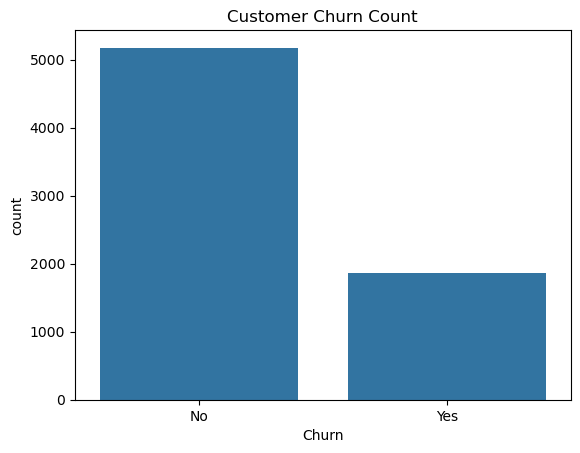

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Count")
plt.show()

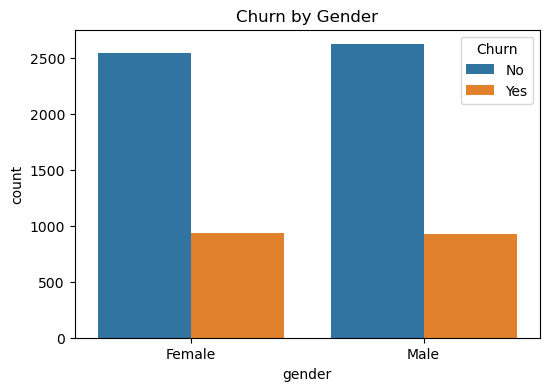

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn by Gender")
plt.show()

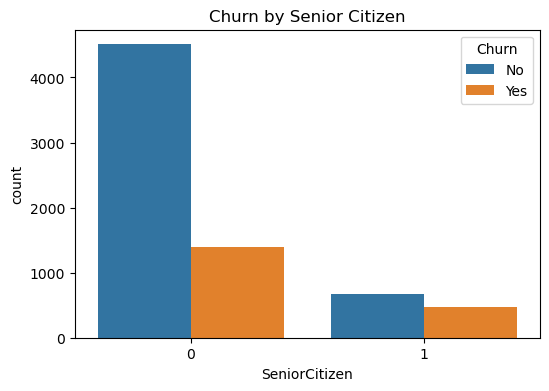

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn by Senior Citizen")
plt.show()

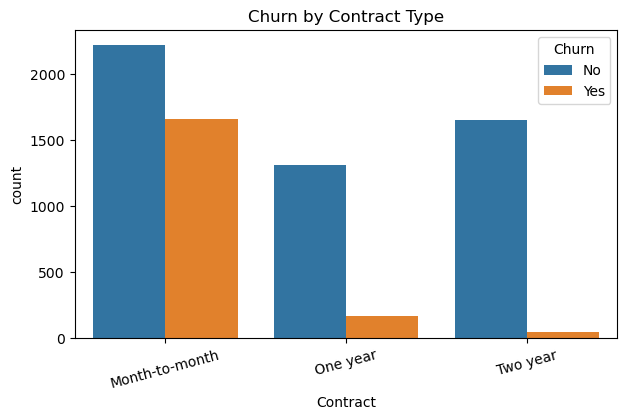

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

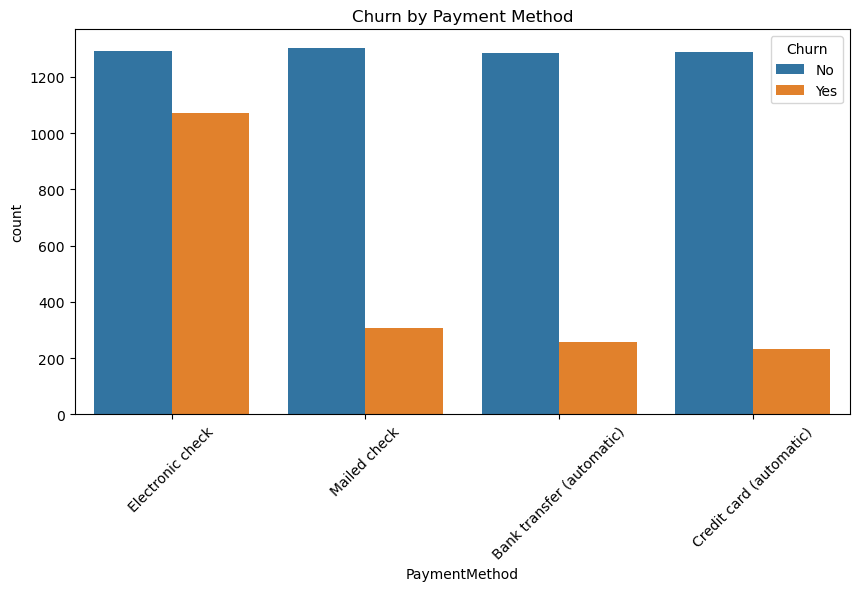

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=45)
plt.show()

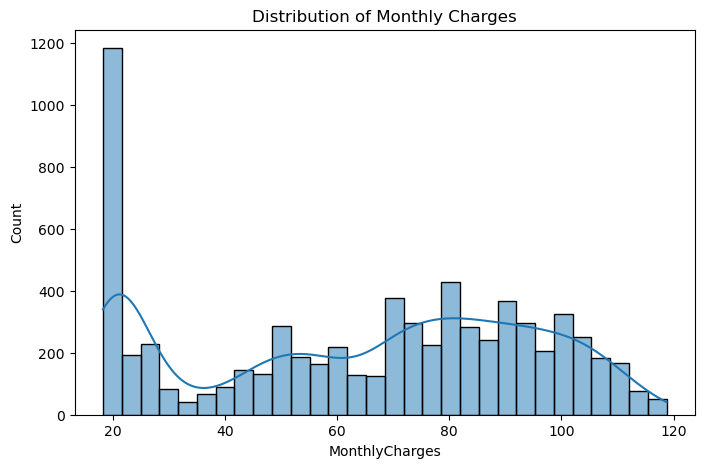

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

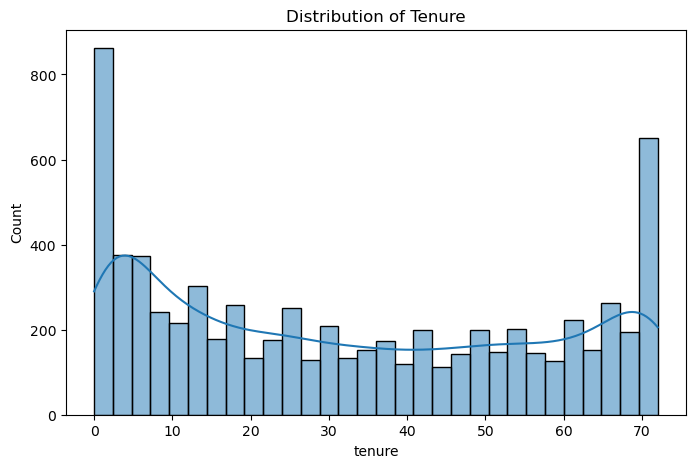

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.show()

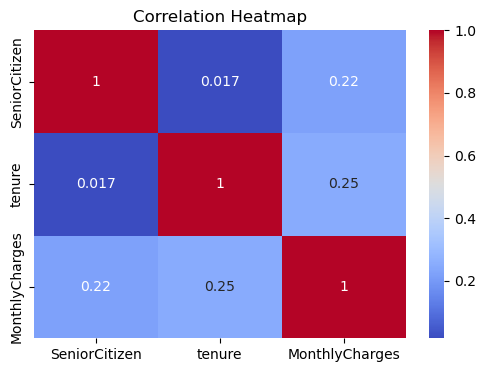

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7970191625266146
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409

[[943  93]
 [193 180]]


In [22]:
import joblib

joblib.dump(model, "../models/churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [23]:
import os

os.makedirs("../models", exist_ok=True)

import joblib
joblib.dump(model, "../models/churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [24]:
joblib.dump(le, "../models/label_encoder.pkl")
print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [25]:
import os
print(os.getcwd())
print(os.listdir("../models"))

C:\Users\likhitha\OneDrive\Documents\Customer-Churn-Prediction\notebooks
['.ipynb_checkpoints', 'churn_model.pkl', 'label_encoder.pkl', 'model_columns.pkl']


In [26]:
import joblib

model_columns = X.columns.tolist()
joblib.dump(model_columns, "../models/model_columns.pkl")

print("model_columns.pkl saved successfully!")

model_columns.pkl saved successfully!


In [27]:
import os

print("Current Folder:", os.getcwd())
print("Models Folder:", os.path.abspath("../models"))
print(os.listdir("../models"))

Current Folder: C:\Users\likhitha\OneDrive\Documents\Customer-Churn-Prediction\notebooks
Models Folder: C:\Users\likhitha\OneDrive\Documents\Customer-Churn-Prediction\models
['.ipynb_checkpoints', 'churn_model.pkl', 'label_encoder.pkl', 'model_columns.pkl']


In [28]:
import os

print(os.path.abspath("../models/churn_model.pkl"))

C:\Users\likhitha\OneDrive\Documents\Customer-Churn-Prediction\models\churn_model.pkl


In [29]:
import os

print("Size:", os.path.getsize("../models/churn_model.pkl"), "bytes")

Size: 16627097 bytes
